In [53]:
#Fraud Detection

In [54]:
import os
import warnings
warnings.filterwarnings('ignore') # To ignore warnings in the output
from IPython.display import display  # To display DataFrames in Jupyter Notebook


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,precision_recall_curve,average_precision_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
try:
    import xgboost as xgb
except ImportError:
    print("XGBoost is not installed. You can install it using 'pip install xgboost'.")


import joblib
print("All libraries imported successfully!")   


All libraries imported successfully!


In [55]:
#Loading the dataset
DATA_PATH='Fraud.csv'
assert os.path.exists(DATA_PATH), f"Dataset not found at {DATA_PATH}"
data = pd.read_csv(DATA_PATH)
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [56]:
df=data
df.head()
print(df['step'].unique())

[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234
 235 236 237 238 239 240 241 242 243 244 245 246 24

In [57]:
print("Dataset shape:", df.shape)
print("\nDataset info:")
print(df.info())
print("\nMissing values in each column:")
print(df.isnull().sum())
print(df['isFraud'].value_counts())
print('Fraud Ratio: {:.4f}%'.format(df['isFraud'].mean() * 100))

Dataset shape: (6362620, 11)

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB
None

Missing values in each column:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64
isFraud
0    6354407
1       8213
Name: count, dtype: int64
Fraud Ratio: 0.1291%


### From the above result we can easily understand there is clear imbalance between the `Fraud` and `Non Fraud`Cases . As a result we should implement methods like `SMOTE(oversampling)` i.e. creating fake fraud data or else we can `undersample` by deleting the non fraud cases. In this case we cant look at the  accuracy_score since the data is imbalanced  and we use `RobustScalar` for this purpose instead of standard scalar because we can clearly see in the amount and transactionedamount there very big outliers and value jump.So RobustScalar basically srinks the value based on median rather than mean used by StandardScalar

amount_bin
(-0.001, 4501.3]             0.000233
(4501.3, 9866.158]           0.000201
(9866.158, 18092.028]        0.000233
(18092.028, 36371.35]        0.000574
(36371.35, 74871.94]         0.000970
(74871.94, 122563.784]       0.000930
(122563.784, 176801.919]     0.000913
(176801.919, 246611.22]      0.000791
(246611.22, 365423.309]      0.001130
(365423.309, 92445516.64]    0.006934
Name: isFraud, dtype: float64


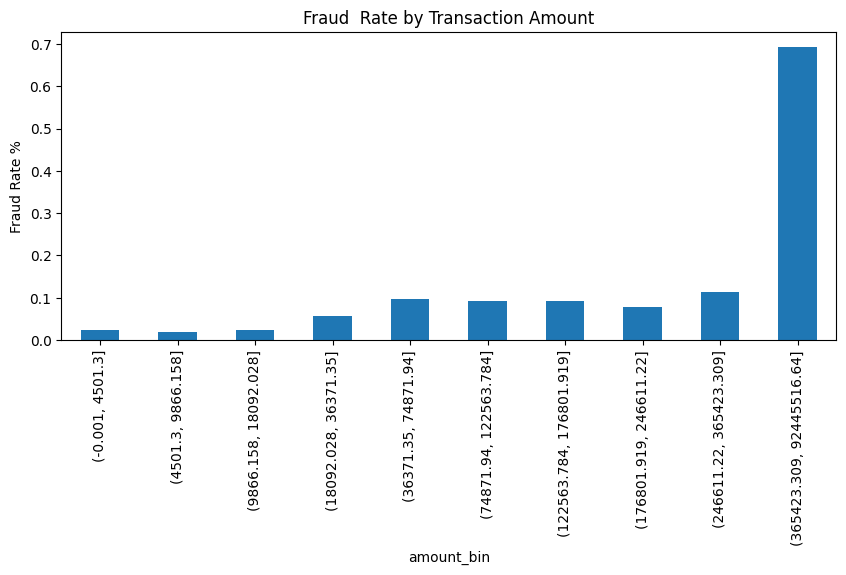

In [58]:
# Fraud Rate  by Amount  Bucket
df['amount_bin'] = pd.qcut(df['amount'], q= 10, duplicates='drop')

fraud_rate = df.groupby('amount_bin')['isFraud'].mean()
print(fraud_rate)

fraud_rate = fraud_rate * 100

plt.figure(figsize=(10,4))
fraud_rate.plot(kind='bar')
plt.ylabel('Fraud Rate %')
plt.title('Fraud  Rate by Transaction Amount')
plt.show()

### Above code  shows an important  insight about the data.The above code basically divides the amount into 10 bins using `qcut` and remove duplicates in the bins also.after that it maps how much percentage are fraud in each bins..the graph shows that as the `amount` increases the chances of fraud activity increases
`Insight`:- If the amount is high more strict checking should be given

In [59]:
print(df['nameDest'].str.startswith('M'))


0           True
1           True
2          False
3          False
4           True
           ...  
6362615    False
6362616    False
6362617    False
6362618    False
6362619    False
Name: nameDest, Length: 6362620, dtype: bool


In [60]:
df.isnull().sum()

merchant_txns = df[df['nameDest'].str.startswith('M')]

print(merchant_txns)
merchant_txns[['oldbalanceDest','newbalanceDest','isFraud']].describe()

         step     type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0           1  PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1           1  PAYMENT   1864.28  C1666544295        21249.0        19384.72   
4           1  PAYMENT  11668.14  C2048537720        41554.0        29885.86   
5           1  PAYMENT   7817.71    C90045638        53860.0        46042.29   
6           1  PAYMENT   7107.77   C154988899       183195.0       176087.23   
...       ...      ...       ...          ...            ...             ...   
6362312   718  PAYMENT   8178.01  C1213413071        11742.0         3563.99   
6362314   718  PAYMENT  17841.23  C1045048098        10182.0            0.00   
6362316   718  PAYMENT   1022.91  C1203084509           12.0            0.00   
6362318   718  PAYMENT   4109.57   C673558958         5521.0         1411.43   
6362319   718  PAYMENT   8634.29   C642813806       518802.0       510167.71   

            nameDest  oldbalanceDest  n

,oldbalanceDest,newbalanceDest,isFraud
count,2151495.0,2151495.0,2151495.0
mean,0.0,0.0,0.0
std,0.0,0.0,0.0
min,0.0,0.0,0.0
25%,0.0,0.0,0.0
50%,0.0,0.0,0.0
75%,0.0,0.0,0.0
max,0.0,0.0,0.0


### From the above results we can easily findout somethings..The first line is used to filter out  NameDest whose names start with 'M' (`they are basically Merchants`).After that we took the describe of the merchant transaction and is there fraud happened with them...The result show that Merchants are `free from frauds` and their transactions can be removed from the dataset since they are free

`Insight` :- Merchants are free from Frauds 

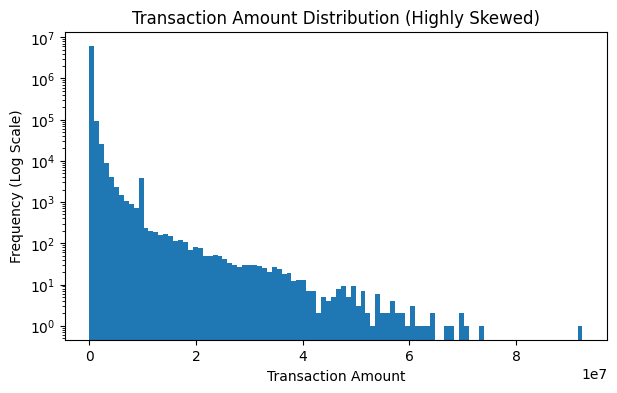

In [61]:
#Outlier handling
df['amount'].describe()

#Visualization

plt.figure(figsize=(7,4))
plt.hist(df['amount'],bins=100)
plt.yscale('log')
plt.xlabel('Transaction Amount')
plt.ylabel("Frequency (Log Scale)")
plt.title("Transaction Amount Distribution (Highly Skewed)")
plt.show()

### This is a histogram where the amount is divided into 100 bins(i.e. the values are divided into 100 scales in ascending order ) the x-axis shows the bin count and y axis shows the people that has amount in that bin ..0 has the biggest bar i.e. around 10^7 people have amount in the first bin (i.e. the small amounts)
`Insight` :- Only a few people have large amount,Here we cannot remove high value amounts since they may be the frauds

In [62]:
df['log_amount'] = np.log1p(df['amount'])

p99 = df['amount'].quantile(0.99)

df['is_high_amount'] = (df['amount']>p99) .astype(int)

df['is_high_amount'].value_counts()

is_high_amount
0    6298993
1      63627
Name: count, dtype: int64

### Here we actually trying to scale the big values into smaller ones and also trying to flag amounts that are high..Because earlier we found out that  `high amount more frauds occur`

In [63]:
# Overview
total_txns =  len(df)
fraud_txns = df['isFraud'].sum()
ratio_fraud = fraud_txns/total_txns
ratio_flagged = df['isFlaggedFraud'].sum()/total_txns
# Convert to percentage by multiplying by 100
print(f"Total Transactions: {total_txns}")
print(f"Fraud Transactions: {fraud_txns}")

# Using f-strings to multiply and format at the same time
print(f"Fraud Ratio: {ratio_fraud * 100:.2f}%")
print(f"Flagged Ratio: {ratio_flagged * 100:.6f}%")

Total Transactions: 6362620
Fraud Transactions: 8213
Fraud Ratio: 0.13%
Flagged Ratio: 0.000251%


### From the above result we can identify that current system cannot identify the frauds where actual frauds occur around 13%

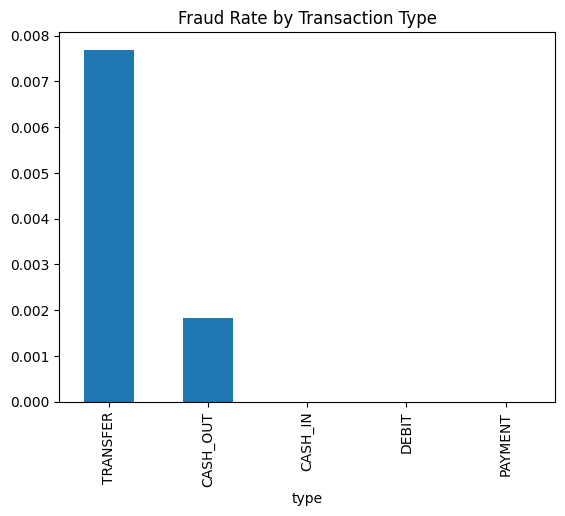

In [64]:
df.groupby('type')['isFraud'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title("Fraud Rate by Transaction Type")
plt.show()

### From the graph its evident that frauds occur only in `Transfer` and `Cash_OUT`

In [65]:
# Time Based  Overview
df['hour'] =  df['step'] % 24

hourly_stats = (
    df.groupby('hour').agg(
        total_transactions = ('isFraud','count'),
        fraud_transactions = ('isFraud','sum'),
        fraud_rate = ('isFraud','mean')
    ).reset_index()
)

display(hourly_stats.head())

,hour,total_transactions,fraud_transactions,fraud_rate
0,0,71587,300,0.004191
1,1,27111,358,0.013205
2,2,9018,372,0.041251
3,3,2007,326,0.162431
4,4,1241,274,0.220790


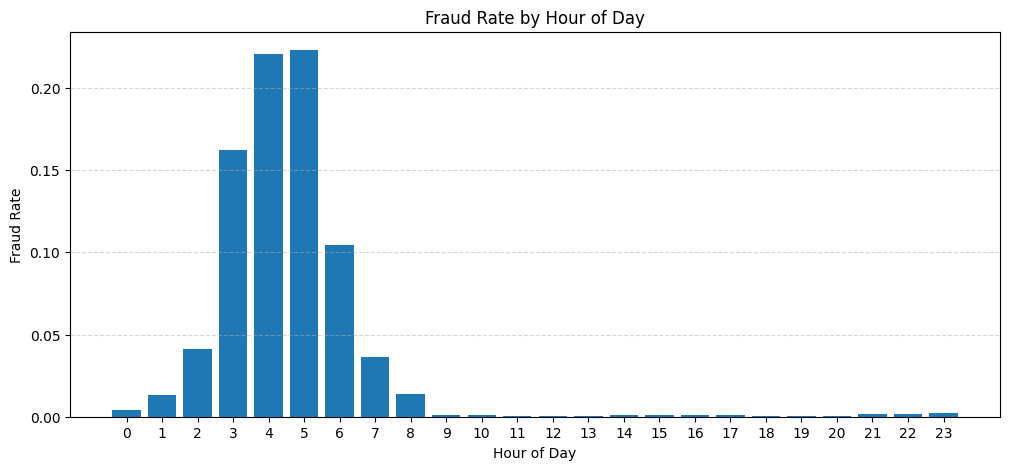

In [66]:
# fraud rate by hour

plt.figure(figsize=(12,5))
plt.bar(hourly_stats['hour'], hourly_stats['fraud_rate'])
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Hour of Day')
plt.xticks(range(0,24))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

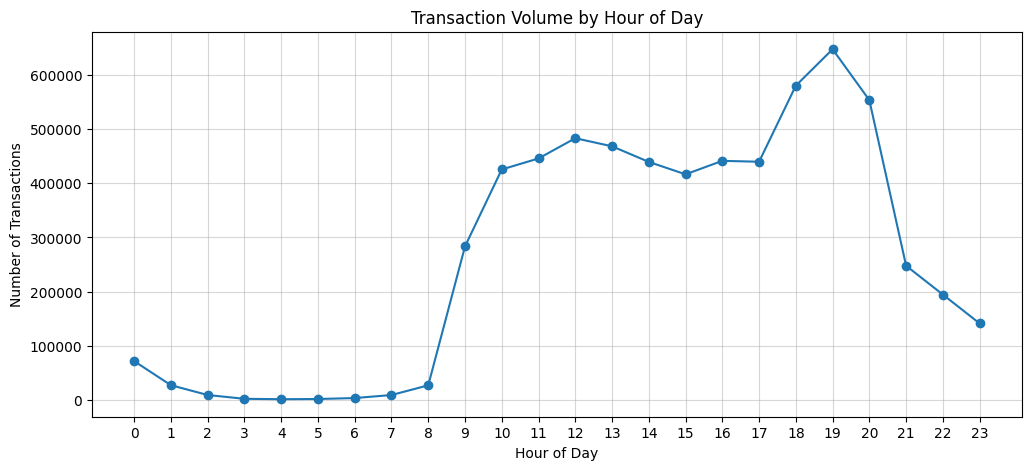

In [67]:
# transaction volume by hour 

plt.figure(figsize=(12,5))
plt.plot(hourly_stats['hour'], hourly_stats['total_transactions'], marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.title('Transaction Volume by Hour of Day')
plt.xticks(range(0,24))
plt.grid(alpha=0.5)
plt.show()

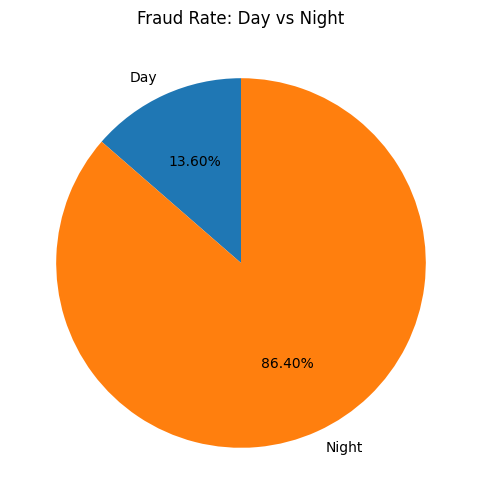

In [68]:
# Day vs Night fraud comparison
plt.figure(figsize=(6,6))

df['is_night'] = df['hour'].isin([0,1,2,3,4,5,22,23]).astype(int)

day_night_fraud = (
    df.groupby('is_night')['isFraud']
      .mean()  # average fraud rate
      .rename({0: 'Day', 1: 'Night'})
)

day_night_fraud.plot(
    kind='pie',
    autopct='%1.2f%%',      
    startangle=90,
    legend=False
)

plt.ylabel('') 
plt.title('Fraud Rate: Day vs Night')
plt.show()

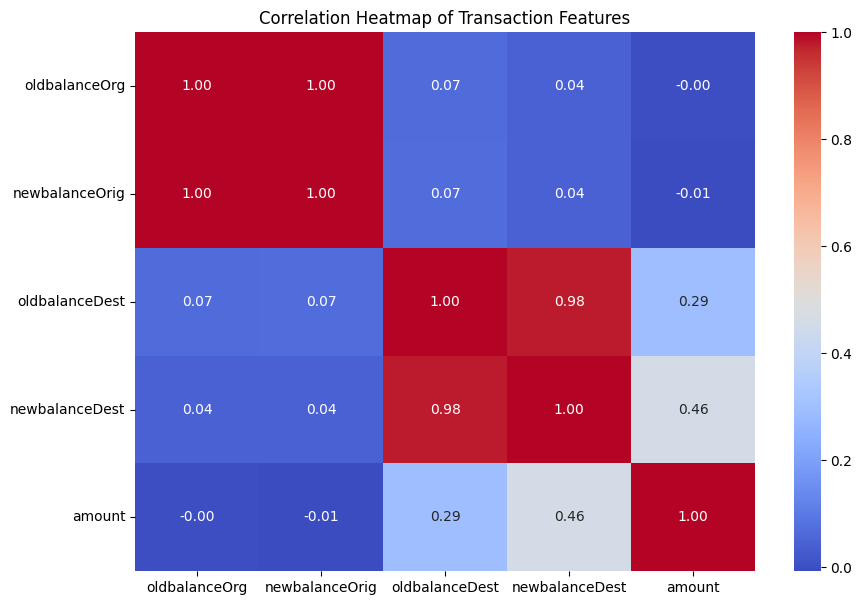

In [69]:
# Correlation Check
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,7))
corr = df[['oldbalanceOrg','newbalanceOrig',
           'oldbalanceDest','newbalanceDest',
           'amount']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Transaction Features')
plt.show()


1. The Red Squares: Multicollinearity

You have two areas of Perfect Correlation (1.00):

    oldbalanceOrg vs newbalanceOrig

    oldbalanceDest vs newbalanceDest (0.98 is also effectively perfect).

What this means: These features are essentially telling the model the same thing. For example, if you know the starting balance and the transaction amount, the ending balance is just simple math.
The Risk: Having perfectly correlated features can "confuse" some models (like Logistic Regression) and lead to overfitting. It makes the model believe these variables are more important than they actually are.
2. The Blue Zones: Independent Features

Look at the intersection of amount and the Origin balances (the dark blue squares with -0.00 and -0.01).

    The Insight: There is zero correlation between the transaction amount and how much money was originally in the account.

    The Interpretation: Wealthy accounts (high oldbalanceOrg) aren't necessarily making larger transactions than poor accounts in this dataset. This suggests that fraudsters might be targeting accounts of all sizes.

3. The "Destination" Connection

Notice that amount has a higher correlation with newbalanceDest (0.46) than with the origin balances.

    Why? Because when a transaction happens, the destination balance must increase by that amount. It proves the "flow" of money is being captured correctly in the data.

In [70]:
# Feature Engineering – Balance Differences
df['balance_diff_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balance_diff_dest'] = df['newbalanceDest'] - df['oldbalanceDest']


# Feature Reduction (for linear models here for logistic regression)
df = df.drop(columns=[
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest'
])

nstead of making the AI analyze four separate snapshots of bank balances—the sender's starting/ending amounts (oldbalanceOrg, newbalanceOrig) and the receiver's starting/ending amounts (oldbalanceDest, newbalanceDest)—you are calculating the actual change in money for both parties.
The Insights behind the code:

    Spotting the "Empty Account" Pattern: By creating balance_diff_orig, you allow the model to see if a transaction emptied an account to exactly zero. In fraud detection, a "perfect drain" (where the amount stolen is exactly the sender's total balance) is a massive red flag.

    Catching "Ghost" Transfers: By creating balance_diff_dest, you can see if money actually "landed." If amount is $10,000 but the destination change is $0, it suggests a suspicious transaction where the money vanished or was routed elsewhere.

    

In [71]:


df.drop(columns=['amount_bin'], inplace=True)
df.fillna(0, inplace=True)

le = LabelEncoder()
df['type_enc'] = le.fit_transform(df['type'])

df.drop(['nameOrig', 'nameDest', 'type'], axis=1, inplace=True)



In [72]:

X = df.drop(columns=['isFraud','isFlaggedFraud'])
y = df['isFraud'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = RobustScaler()
num_cols = X_train.select_dtypes(include=[np.number]).columns
scaler.fit(X_train[num_cols])

X_train[num_cols] = scaler.transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])



In [73]:
models = {}

# Logistic Regression 

print("Training Logistic Regression (fast mode)...")
lr = LogisticRegression(
    max_iter=300,                  # reduced iterations
    solver='lbfgs',                
    class_weight='balanced',
    n_jobs=-1
)
lr.fit(X_train, y_train)
models['LogisticRegression'] = lr
print("Logistic Regression trained")

# Random Forest 

print("Training Random Forest (optimized)...")
rf = RandomForestClassifier(
    n_estimators=50,               # reduced trees
    max_depth=12,                  # cap tree growth
    min_samples_leaf=100,          # prevent deep splits
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
models['RandomForest'] = rf
print("Random Forest trained")

# XGBoost 

if xgb is not None:
    print("Training XGBoost (fast hist)...")
    scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

    xgb_model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        scale_pos_weight=scale_pos,
        tree_method='hist',         
        n_jobs=-1
    )
    xgb_model.fit(X_train, y_train)
    models['XGBoost'] = xgb_model
    print("XGBoost trained")
else:
    print("XGBoost not installed")

Training Logistic Regression (fast mode)...
Logistic Regression trained
Training Random Forest (optimized)...
Random Forest trained
Training XGBoost (fast hist)...
XGBoost trained


In [74]:
results = []
for name, model in models.items():
    if hasattr(model,'predict_proba'):
        scores = model.predict_proba(X_test)[:,1]
    else:
        scores = model.decision_function(X_test)
    print('\n',name)
    print(classification_report(y_test, (scores>0.5).astype(int)))
    results.append({'model':name,'roc_auc':roc_auc_score(y_test,scores),'auprc':average_precision_score(y_test,scores)})

pd.DataFrame(results).sort_values('auprc', ascending=False)



 LogisticRegression
              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1270881
           1       0.03      0.89      0.05      1643

    accuracy                           0.96   1272524
   macro avg       0.51      0.93      0.52   1272524
weighted avg       1.00      0.96      0.98   1272524


 RandomForest
              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1270881
           1       0.07      0.96      0.12      1643

    accuracy                           0.98   1272524
   macro avg       0.53      0.97      0.56   1272524
weighted avg       1.00      0.98      0.99   1272524


 XGBoost
              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1270881
           1       0.06      0.97      0.11      1643

    accuracy                           0.98   1272524
   macro avg       0.53      0.97      0.55   1272524
weighted avg       1.00     

,model,roc_auc,auprc
2,XGBoost,0.998054,0.875526
1,RandomForest,0.997632,0.841487
0,LogisticRegression,0.977524,0.550562


In [75]:
from sklearn.metrics import precision_recall_curve

model = models['XGBoost'] 

y_scores = model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# Find threshold with recall >= 0.90 and best precision
candidates = [
    (t, p, r) for t, p, r in zip(thresholds, precision[:-1], recall[:-1])
    if r >= 0.90
]

best_threshold, best_p, best_r = max(candidates, key=lambda x: x[1])
print(f"Best threshold: {best_threshold:.4f}")
print(f"Precision: {best_p:.3f}, Recall: {best_r:.3f}")


Best threshold: 0.9131
Precision: 0.339, Recall: 0.900


In [76]:
from xgboost import XGBClassifier

xgb_tuned = XGBClassifier(
    n_estimators=200,
    max_depth=4,                 # controls overfitting
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=50,         # critical for imbalance
    scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
    eval_metric='logloss',
    tree_method='hist',
    n_jobs=-1
)

xgb_tuned.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [77]:
lr_tuned = LogisticRegression(
    max_iter=300,
    solver='lbfgs',
    class_weight='balanced',
    C=0.3                     # stronger regularization
)

lr_tuned.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.3
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [78]:
rf_tuned = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=200,        # huge impact on precision
    min_samples_split=500,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

rf_tuned.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",500
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",200
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metr

In [79]:

from sklearn.metrics import roc_auc_score, average_precision_score

def evaluate(model, X, y):
    scores = model.predict_proba(X)[:,1]
    return {
        "ROC-AUC": roc_auc_score(y, scores),
        "PR-AUC": average_precision_score(y, scores)
    }

print("XGB:", evaluate(xgb_tuned, X_test, y_test))
print("RF :", evaluate(rf_tuned, X_test, y_test))
print("LR :", evaluate(lr_tuned, X_test, y_test))



XGB: {'ROC-AUC': 0.9982141722484371, 'PR-AUC': 0.8622614125367911}
RF : {'ROC-AUC': 0.9977525113469302, 'PR-AUC': 0.8320049214362165}
LR : {'ROC-AUC': 0.9774936739612738, 'PR-AUC': 0.5504119584396517}


In [80]:


models = {
    "LogisticRegression": lr_tuned,
    "RandomForest": rf_tuned,
    "XGBoost": xgb_tuned
}

best_model_name = max(results, key=lambda x: x['auprc'])['model']
best_model = models[best_model_name]


best_model_artifact = {
    "model_name": best_model_name,
    "model": best_model,
    "threshold": best_threshold,     
    "features": X_train.columns.tolist()
}

joblib.dump(best_model_artifact, "best_fraud_model_tuned.pkl")

print(f" Saved best model: {best_model_name}")
print(f" Decision threshold: {best_threshold:.4f}")



 Saved best model: XGBoost
 Decision threshold: 0.9131


In [81]:
# Load saved model artifact
artifact = joblib.load("best_fraud_model_tuned.pkl")
model = artifact["model"]
threshold = artifact["threshold"]
features = artifact["features"]

# Predict on test data
y_scores = model.predict_proba(X_test[features])[:, 1]
y_pred = (y_scores >= threshold).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Summary table
summary = pd.DataFrame({
    "Count": [tp, fn, fp, tn]
}, index=[
    "Correctly detected fraud (TP)",
    "Missed fraud (FN)",
    "False alarms (FP)",
    "Correct non-fraud (TN)"
])

print(summary)

# quick fraud recall check
print(f"\nFraud Recall: {tp / (tp + fn):.3f}")
print(f"Fraud Precision: {tp / (tp + fp):.3f}")


                                 Count
Correctly detected fraud (TP)     1471
Missed fraud (FN)                  172
False alarms (FP)                 3361
Correct non-fraud (TN)         1267520

Fraud Recall: 0.895
Fraud Precision: 0.304
